Aprendizaje Automatico 1

Trabajo Práctico Nº 2

Integrantes: Quinteros, Lasarte, Lazarte

# 1 — Análisis Descriptivo

Columnas:


*   Date (Temporal): Fecha del registro (formato año-mes-día).
*   Location (Catagórica): Ciudad meteorológica donde se tomó la medición.
*   MinTemp (Numérica): Temperatura mínima del día (°C).
*   MaxTemp (Numérica): Temperatura máxima del día (°C).
*   Rainfall (Numérica): Cantidad de lluvia caída en el día (mm).
*   Evaporatio (Numérica): Cantidad de agua evaporada (mm).
*   Sunshine (Numérica): Horas de sol durante el día.
*   WindGustDir (Catagórica): Dirección de la ráfaga de viento más fuerte.
*   WindGustSpeed (Numérica): Velocidad máxima de ráfaga de viento (km/h).
*   WindDir9am (Catagórica): Dirección del viento a las 9 am.
*   WindDir3pm (Catagórica): Dirección del viento a las 3 pm.
*   WindSpeed9am (Numérica): Velocidad del viento a las 9 am.
*   WindSpeed3pm (Numérica): Velocidad del viento a las 3 pm.
*   Humidity9am (Numérica): Humedad relativa (%) a las 9 am.
*   Humidity3pm (Numérica): Humedad relativa (%) a las 3 pm.
*   Pressure9am (Numérica): Presión atmosférica (hPa) a las 9 am.
*   Pressure3pm (Numérica): Presión atmosférica (hPa) a las 3 pm.
*   Cloud9am (Numérica): Nubosidad a las 9 am (escala de 0 a 8, donde 8 es cielo totalmente cubierto).
*   Cloud3pm (Numérica): Nubosidad a las 3 pm.
*   Temp9am (Numérica): Temperatura medida a las 9 am.
*   Temp3pm (Numérica): Temperatura medida a las 3 pm.
*   RainToday (Catagórica): Indica si llovió ese día (Yes/No).
*   RainTomorrow (Catagórica): Indica si va a llover al día siguiente.
*   RainfallTomorrow (Numérica): Cantidad de lluvia del día siguiente (mm).



In [81]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import time
import optuna

In [55]:
clima = pd.read_csv('weatherAUS_2026C1.csv')

In [56]:
clima.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [57]:
clima.info()

<class 'pandas.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  str    
 2   Location          145412 non-null  str    
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  str    
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  str    
 11  WindDir3pm        141186 non-null  str    
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null  float64
 16  Pressure9am       130351 non-nu

In [58]:
clima.describe()

,Unnamed: 0,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainfallTomorrow
count,145412.000000,143928.000000,144159.000000,142152.000000,82658.000000,75616.000000,135159.000000,143645.000000,142351.000000,142759.000000,140907.000000,130351.000000,130388.000000,89542.000000,86076.000000,143646.000000,141805.000000,142153.000000
mean,72728.184393,12.196528,23.223064,2.361516,5.468616,7.611241,40.036668,14.067277,18.661899,68.861521,51.532206,1017.647237,1015.255080,4.447287,4.509770,16.991981,21.683360,2.361242
std,41990.722236,6.417956,7.135927,8.479338,4.193871,3.785612,13.648259,8.936768,8.865457,19.062866,20.844414,7.113833,7.044507,2.887161,2.720306,6.509191,6.953072,8.479084
min,0.000000,-9.700000,-5.100000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.300000,977.400000,0.000000,0.000000,-8.000000,-5.800000,0.000000
25%,36362.750000,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,12.000000,57.000000,36.600000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,72727.500000,12.000000,22.600000,0.000000,4.800000,8.400000,38.000000,13.000000,18.000000,69.900000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,109093.250000,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.100000,65.700000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,145458.000000,34.100000,49.100000,371.000000,145.000000,14.500000,135.000000,130.000000,86.000000,100.000000,100.000000,1041.200000,1039.800000,9.000000,9.000000,39.800000,47.000000,371.000000


In [59]:
clima = clima.drop('Unnamed: 0', axis = 1) # Se borra porque es simplemente un índice (contador de filas). No aporta información meteorológica.

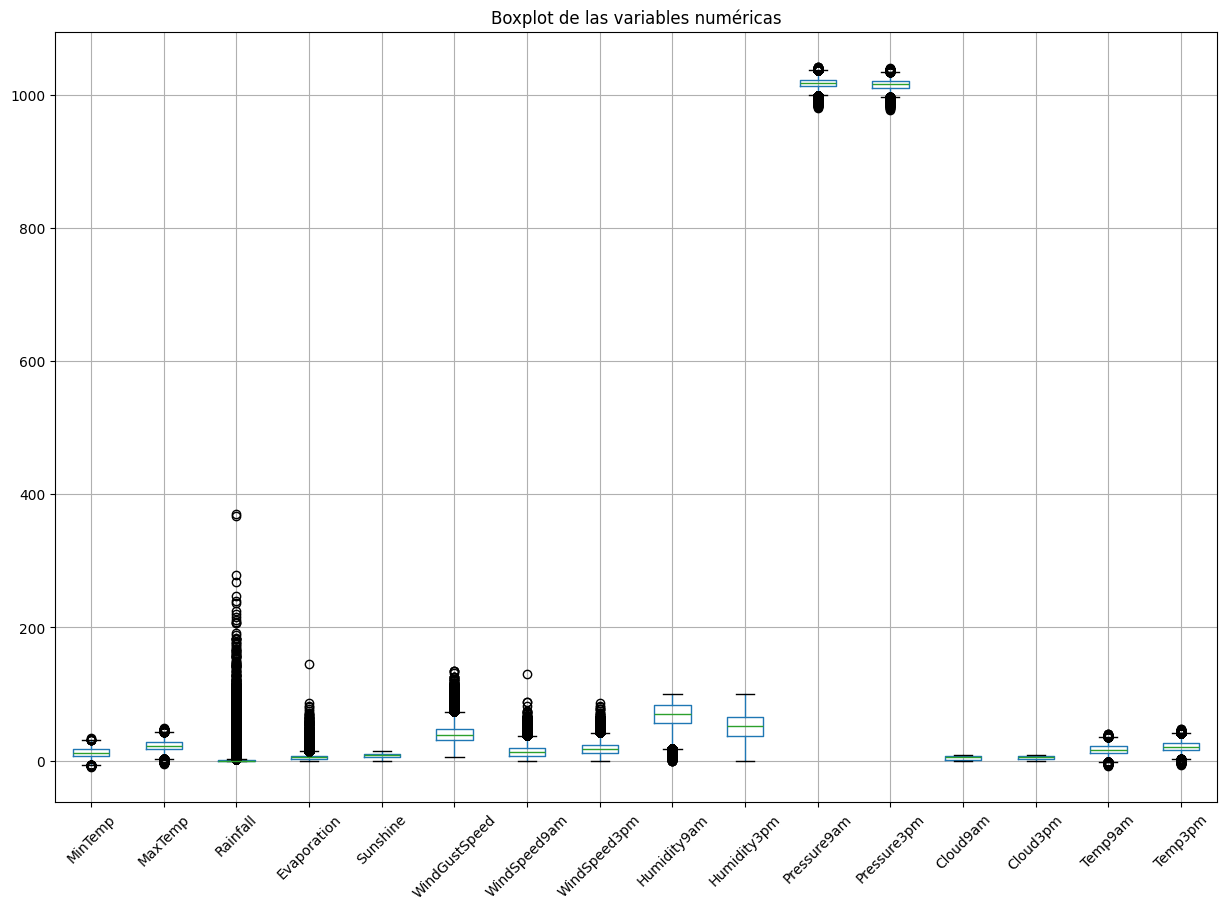

In [60]:
boxplot = clima.boxplot(column=['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm'], figsize=(15, 10))
plt.title('Boxplot de las variables numéricas')
plt.xticks(rotation=45)
plt.show()

In [61]:
print("Cantidad de valores NaN:")
print(f"\n{clima.isnull().sum()}")

Cantidad de valores NaN:

Date                    0
Location                0
MinTemp              1484
MaxTemp              1253
Rainfall             3260
Evaporation         62754
Sunshine            69796
WindGustDir         10316
WindGustSpeed       10253
WindDir9am          10562
WindDir3pm           4226
WindSpeed9am         1767
WindSpeed3pm         3061
Humidity9am          2653
Humidity3pm          4505
Pressure9am         15061
Pressure3pm         15024
Cloud9am            55870
Cloud3pm            59336
Temp9am              1766
Temp3pm              3607
RainToday            3260
RainTomorrow         3259
RainfallTomorrow     3259
dtype: int64


In [62]:
#porcentaje de valores nulos por variable
print("\nPorcentaje de valores NaN:")
print(f"\n{(clima.isnull().sum() / len(clima)) * 100}")


Porcentaje de valores NaN:

Date                 0.000000
Location             0.000000
MinTemp              1.020549
MaxTemp              0.861690
Rainfall             2.241906
Evaporation         43.155998
Sunshine            47.998790
WindGustDir          7.094325
WindGustSpeed        7.051000
WindDir9am           7.263500
WindDir3pm           2.906225
WindSpeed9am         1.215168
WindSpeed3pm         2.105053
Humidity9am          1.824471
Humidity3pm          3.098094
Pressure9am         10.357467
Pressure3pm         10.332022
Cloud9am            38.421863
Cloud3pm            40.805436
Temp9am              1.214480
Temp3pm              2.480538
RainToday            2.241906
RainTomorrow         2.241218
RainfallTomorrow     2.241218
dtype: float64


In [80]:
outliers = {}

# Solo columnas numéricas
cols_num = clima.select_dtypes(include=['int64', 'float64']).columns

for col in cols_num:
    Q1 = clima[col].quantile(0.25)
    Q3 = clima[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    cantidad = ((clima[col] < limite_inf) | 
                 (clima[col] > limite_sup)).sum()

    outliers[col] = cantidad

# Convertimos a DataFrame para verlo prolijo
df_outliers = pd.DataFrame.from_dict(outliers, orient='index', columns=['Cantidad_atipicos'])

print(df_outliers.sort_values(by='Cantidad_atipicos', ascending=False))

               Cantidad_atipicos
RainTomorrow               31872
Rainfall                   25224
WindGustSpeed               2899
Evaporation                 1954
WindSpeed9am                1891
WindSpeed3pm                1663
Humidity9am                 1425
Pressure9am                 1181
Pressure3pm                  915
Temp3pm                      752
MaxTemp                      485
Temp9am                      255
MinTemp                       60
Humidity3pm                    0
Sunshine                       0
Cloud3pm                       0
Cloud9am                       0
Month_sin                      0
Month_cos                      0


In [63]:
#limpieza pre-split: sacamos columnas leakage, filas sin target y encodeamos
clima = clima.drop(columns=['RainfallTomorrow'])
clima = clima.dropna(subset=['RainTomorrow'])
clima['RainTomorrow'] = clima['RainTomorrow'].map({'No': 0, 'Yes': 1}).astype(int)

In [64]:
#extraemos month de Date y lo encodeamos cíclico para el modelo
clima['Date'] = pd.to_datetime(clima['Date'])
clima['Month'] = clima['Date'].dt.month
clima['Month_sin'] = np.sin(2 * np.pi * clima['Date'].dt.month / 12)
clima['Month_cos'] = np.cos(2 * np.pi * clima['Date'].dt.month / 12)
clima = clima.drop(columns=['Date'])

#Separamos features y targets
X = clima.drop(columns=['RainTomorrow'])
y = clima['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(113722, 24) (28431, 24)


In [66]:
conteo = y_train.value_counts()
porcentaje = y_train.value_counts(normalize=True) * 100

print("Conteo:")
print(conteo)

print("\nPorcentaje:")
print(porcentaje)

Conteo:
RainTomorrow
0    88224
1    25498
Name: count, dtype: int64

Porcentaje:
RainTomorrow
0    77.578657
1    22.421343
Name: proportion, dtype: float64


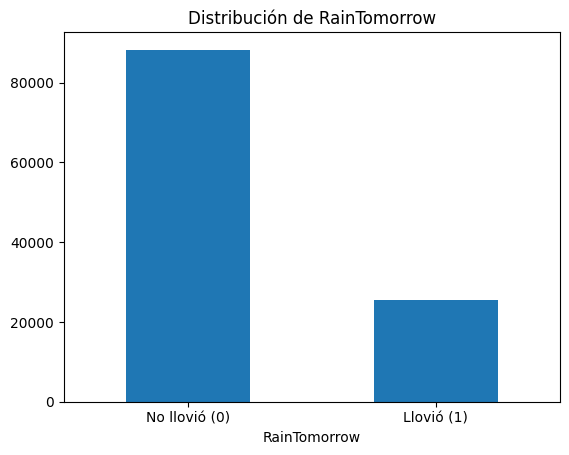

In [67]:
y_train.value_counts().plot(kind='bar')
plt.title('Distribución de RainTomorrow')
plt.xticks([0, 1], ['No llovió (0)', 'Llovió (1)'], rotation=0)
plt.xlabel('RainTomorrow')
plt.show()

El Dataset está claramente desbalanceado, por lo que se deberá solucionar este problema más adelante

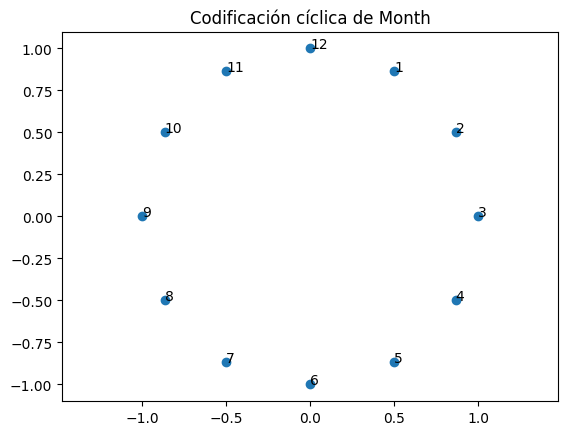

In [ ]:
months_test = np.arange(1, 13)
plt.scatter(np.sin(2*np.pi*months_test/12), np.cos(2*np.pi*months_test/12))
for m in months_test:
    plt.annotate(str(m), (np.sin(2*np.pi*m/12), np.cos(2*np.pi*m/12)))
plt.title('Codificación cíclica de Month')
plt.axis('equal')
plt.show()

Tratamiento de NaNs:

* Se crean copias de X_train y X_test.
* Rainfall se completa con 0 y RainToday con "No".
* Se generan columnas _missing para indicar qué valores originalmente eran NaN.
* Las variables categóricas del viento (WindGustDir, WindDir9am, WindDir3pm) se imputan usando la moda en cascada:
    primero por Location + Month,
    luego por Location,
    y finalmente una moda global.
* Las variables numéricas más estables (temperaturas, humedades y velocidades de viento) se imputan usando mediana en cascada.
* Las variables de nubosidad (Cloud9am, Cloud3pm) se imputan aleatoriamente usando valores reales del train para preservar la distribución original.
* Las variables más sensibles (Pressure9am, Pressure3pm, Evaporation, Sunshine) se imputan mediante KNNImputer, que estima valores usando observaciones similares y conserva mejor las relaciones entre variables.
* RainToday se convierte de "Yes"/"No" a 1/0.
* Se eliminan Location y Month porque solo se utilizaron para agrupar durante la imputación.
* Las variables categóricas del viento se transforman mediante One-Hot Encoding.
* Finalmente, se igualan las columnas entre train y test y se verifica que no queden valores faltantes.

In [82]:
X1_train = X_train.copy()
X1_test = X_test.copy()

for X in [X1_train, X1_test]:
    X['Rainfall'] = X['Rainfall'].fillna(0)
    X['RainToday'] = X['RainToday'].fillna('No')

cols_flag = [
    'Humidity9am','Humidity3pm',
    'Pressure9am','Pressure3pm',
    'Temp9am','Temp3pm',
    'Cloud9am','Cloud3pm',
    'Evaporation','Sunshine'
]

for c in cols_flag:
    X1_train[c + '_missing'] = X1_train[c].isna().astype(int)
    X1_test[c + '_missing'] = X1_test[c].isna().astype(int)

def imputar_cascada(X, col, stat_loc_month, stat_loc, stat_global):

    keys = pd.MultiIndex.from_arrays(
        [X['Location'].values, X['Month'].values]
    )

    vals = stat_loc_month.reindex(keys).values

    X[col] = X[col].fillna(pd.Series(vals, index=X.index))
    X[col] = X[col].fillna(X['Location'].map(stat_loc))
    X[col] = X[col].fillna(stat_global)

for c in ['WindGustDir','WindDir9am','WindDir3pm']:

    moda_global = X1_train[c].mode(dropna=True).iloc[0]

    modas_loc = X1_train.groupby('Location')[c].agg(
        lambda x: x.mode().iloc[0]
        if not x.mode().empty else moda_global
    )

    modas_loc_month = X1_train.groupby(
        ['Location','Month']
    )[c].agg(
        lambda x: x.mode().iloc[0]
        if not x.mode().empty else np.nan
    )

    for X in [X1_train, X1_test]:
        imputar_cascada(
            X, c,
            modas_loc_month,
            modas_loc,
            moda_global
        )

cols_mediana = [
    'MinTemp','MaxTemp',
    'WindGustSpeed',
    'WindSpeed9am','WindSpeed3pm',
    'Humidity9am','Humidity3pm',
    'Temp9am','Temp3pm'
]

for c in cols_mediana:

    med_global = X1_train[c].median()

    meds_loc = X1_train.groupby('Location')[c].median()

    meds_loc_month = X1_train.groupby(
        ['Location','Month']
    )[c].median()

    for X in [X1_train, X1_test]:

        imputar_cascada(
            X, c,
            meds_loc_month,
            meds_loc,
            med_global
        )

def imputacion_random(train, test, col):

    valores_train = train[col].dropna().values

    mask_train = train[col].isna()

    train.loc[mask_train, col] = np.random.choice(
        valores_train,
        size=mask_train.sum(),
        replace=True
    )

    mask_test = test[col].isna()

    test.loc[mask_test, col] = np.random.choice(
        valores_train,
        size=mask_test.sum(),
        replace=True
    )

for c in ['Cloud9am', 'Cloud3pm']:

    imputacion_random(X1_train, X1_test, c)

cols_knn = [
    'Pressure9am','Pressure3pm',
    'Evaporation','Sunshine'
]

imputer = KNNImputer(n_neighbors=5)

X1_train[cols_knn] = imputer.fit_transform(
    X1_train[cols_knn]
)

X1_test[cols_knn] = imputer.transform(
    X1_test[cols_knn]
)

for X in [X1_train, X1_test]:

    X['RainToday'] = X['RainToday'].map({
        'Yes': 1,
        'No': 0
    }).astype(int)

X1_train = X1_train.drop(
    columns=['Location','Month']
)

X1_test = X1_test.drop(
    columns=['Location','Month']
)

X1_train = pd.get_dummies(
    X1_train,
    columns=['WindGustDir','WindDir9am','WindDir3pm']
)

X1_test = pd.get_dummies(
    X1_test,
    columns=['WindGustDir','WindDir9am','WindDir3pm']
)

X1_test = X1_test.reindex(
    columns=X1_train.columns,
    fill_value=0
)

print(
    'X1:',
    X1_train.shape,
    X1_test.shape,
    '| NaN:',
    X1_train.isnull().sum().sum(),
    X1_test.isnull().sum().sum()
)

X1: (113722, 77) (28431, 77) | NaN: 0 0


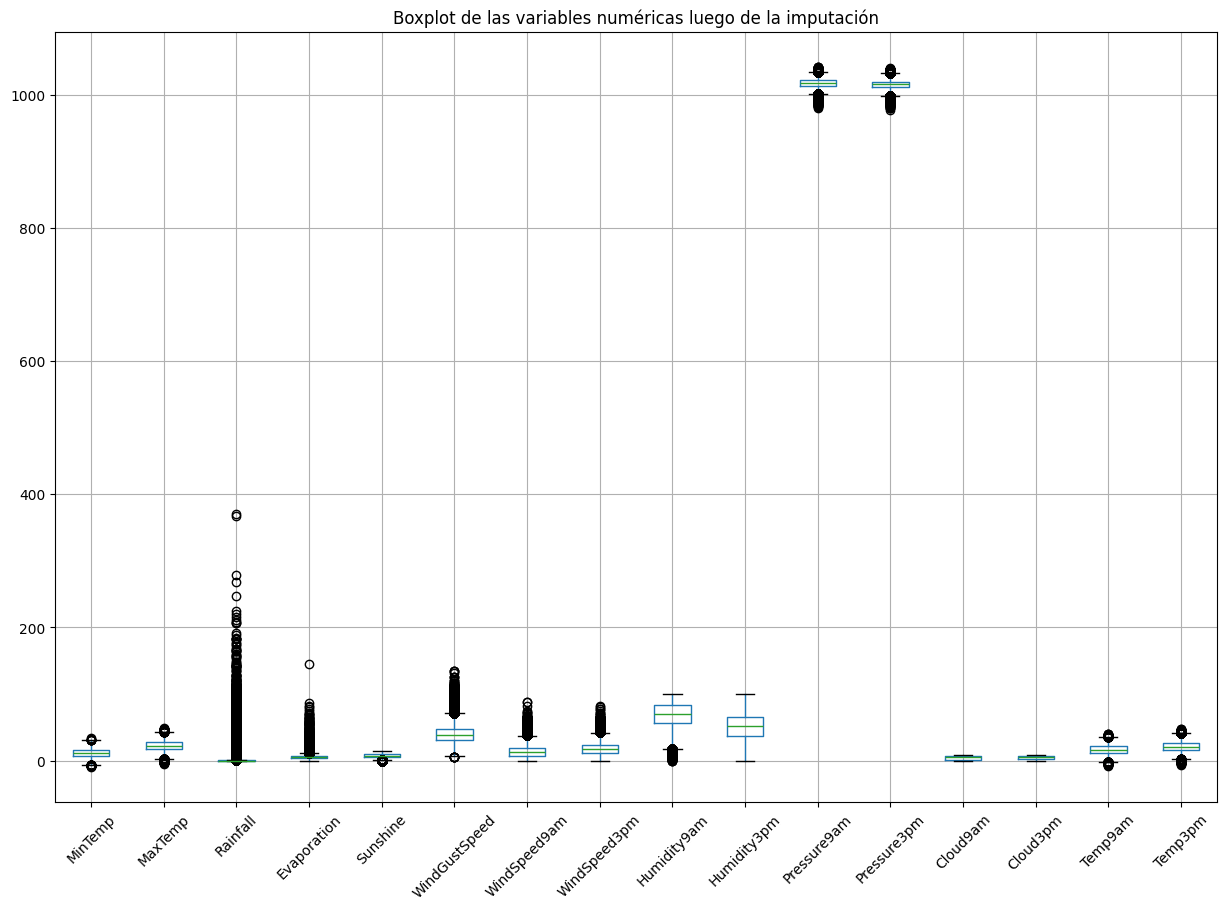

In [83]:
boxplot = X1_train.boxplot(column=['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm'], figsize=(15, 10))
plt.title('Boxplot de las variables numéricas luego de la imputación')
plt.xticks(rotation=45)
plt.show()

In [84]:
outliers = {}

# Solo columnas numéricas
cols_num = X1_train.select_dtypes(include=['int64', 'float64']).columns

for col in cols_num:
    Q1 = X1_train[col].quantile(0.25)
    Q3 = X1_train[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    cantidad = ((X1_train[col] < limite_inf) | 
                 (X1_train[col] > limite_sup)).sum()

    outliers[col] = cantidad

# Convertimos a DataFrame para verlo prolijo
df_outliers = pd.DataFrame.from_dict(outliers, orient='index', columns=['Cantidad_atipicos'])

print(df_outliers.sort_values(by='Cantidad_atipicos', ascending=False))

                     Cantidad_atipicos
RainToday                        25121
Rainfall                         22829
Pressure9am_missing              11291
Pressure3pm_missing              11274
Evaporation                       3635
Sunshine                          3546
Humidity3pm_missing               2916
WindGustSpeed                     2874
Temp3pm_missing                   2206
Pressure9am                       2160
Pressure3pm                       1843
WindSpeed9am                      1497
Humidity9am_missing               1427
WindSpeed3pm                      1308
Humidity9am                       1159
Temp9am_missing                    727
Temp3pm                            609
MaxTemp                            393
Temp9am                            202
MinTemp                             51
Humidity3pm                          0
Cloud9am                             0
Month_sin                            0
Cloud3pm                             0
Month_cos                

Agregar Comentario

In [86]:
print("Cantidad de valores NaN:")
print(f"\n{X1_train.isnull().sum()}")

Cantidad de valores NaN:

MinTemp           0
MaxTemp           0
Rainfall          0
Evaporation       0
Sunshine          0
                 ..
WindDir3pm_SSW    0
WindDir3pm_SW     0
WindDir3pm_W      0
WindDir3pm_WNW    0
WindDir3pm_WSW    0
Length: 77, dtype: int64


In [87]:
X1_test.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Humidity9am_missing,Humidity3pm_missing,Pressure9am_missing,Pressure3pm_missing,Temp9am_missing,Temp3pm_missing,Cloud9am_missing,Cloud3pm_missing,Evaporation_missing,Sunshine_missing
count,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,...,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000,28431.000000
mean,12.252052,23.294568,2.279209,5.454818,7.637984,39.971281,14.034452,18.599328,68.818049,51.430776,...,0.012205,0.024375,0.095635,0.095072,0.006226,0.018255,0.378179,0.400162,0.425521,0.473392
std,6.404800,7.141904,7.925567,3.400829,2.991577,13.207054,8.913141,8.875466,19.013404,20.780403,...,0.109802,0.154213,0.294095,0.293320,0.078658,0.133874,0.484941,0.489940,0.494431,0.499300
min,-7.600000,-3.800000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.700000,18.000000,0.000000,3.380000,6.020000,31.000000,7.000000,12.000000,57.000000,36.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,12.100000,22.700000,0.000000,5.360000,7.617550,38.000000,13.000000,18.000000,69.700000,51.900000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,16.900000,28.300000,0.800000,6.800000,9.760000,47.000000,19.000000,24.000000,82.900000,65.400000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
max,31.600000,46.900000,240.000000,64.000000,14.100000,125.000000,130.000000,86.000000,100.000000,100.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


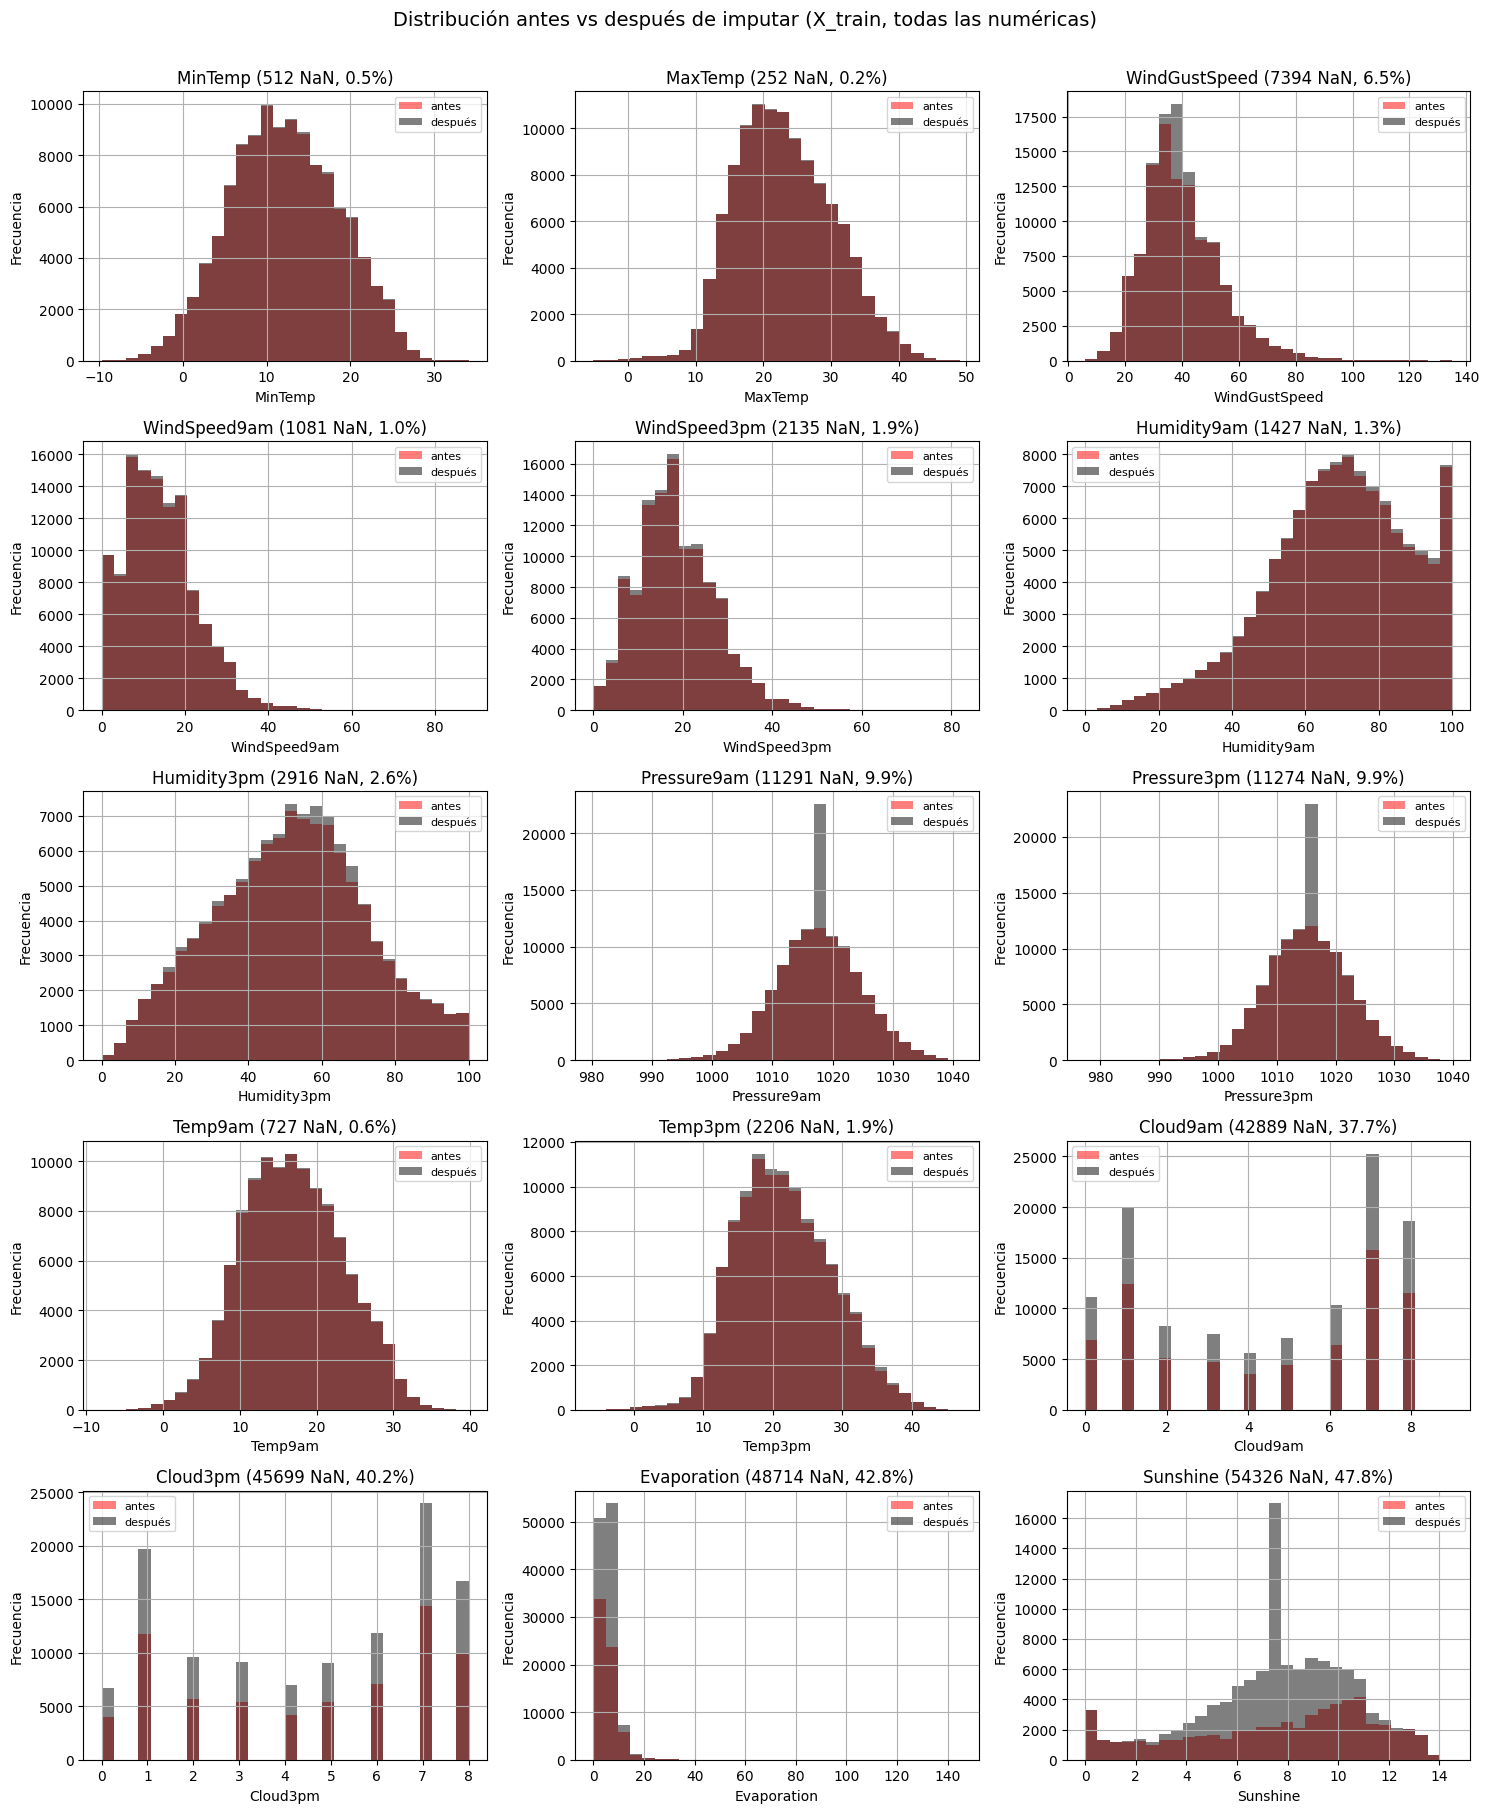

In [88]:
#comparar distribuciones antes vs después de imputar (X_train)
#para todas las variables numéricas que pasaron por la cascada

vars_num = ['MinTemp', 'MaxTemp', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
            'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
            'Temp9am', 'Temp3pm', 'Cloud9am', 'Cloud3pm', 'Evaporation', 'Sunshine']

fig, axes = plt.subplots(5, 3, figsize=(15, 18))

for i, c in enumerate(vars_num):
    ax = axes[i // 3, i % 3]
    X_train[c].dropna().hist(ax=ax, bins=30, alpha=0.5, color='red', label='antes')
    X1_train[c].hist(ax=ax, bins=30, alpha=0.5, color='black', label='después')
    n_imp = X_train[c].isna().sum()
    pct = round(100 * n_imp / len(X_train), 1)
    ax.set_title(f'{c} ({n_imp} NaN, {pct}%)')
    ax.set_xlabel(c)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.suptitle('Distribución antes vs después de imputar (X_train, todas las numéricas)',
             fontsize=14, y=1.005)
plt.tight_layout()
plt.show()


Podemos ver el antes y el despues de las imputaciones. 
Agregar comentarios

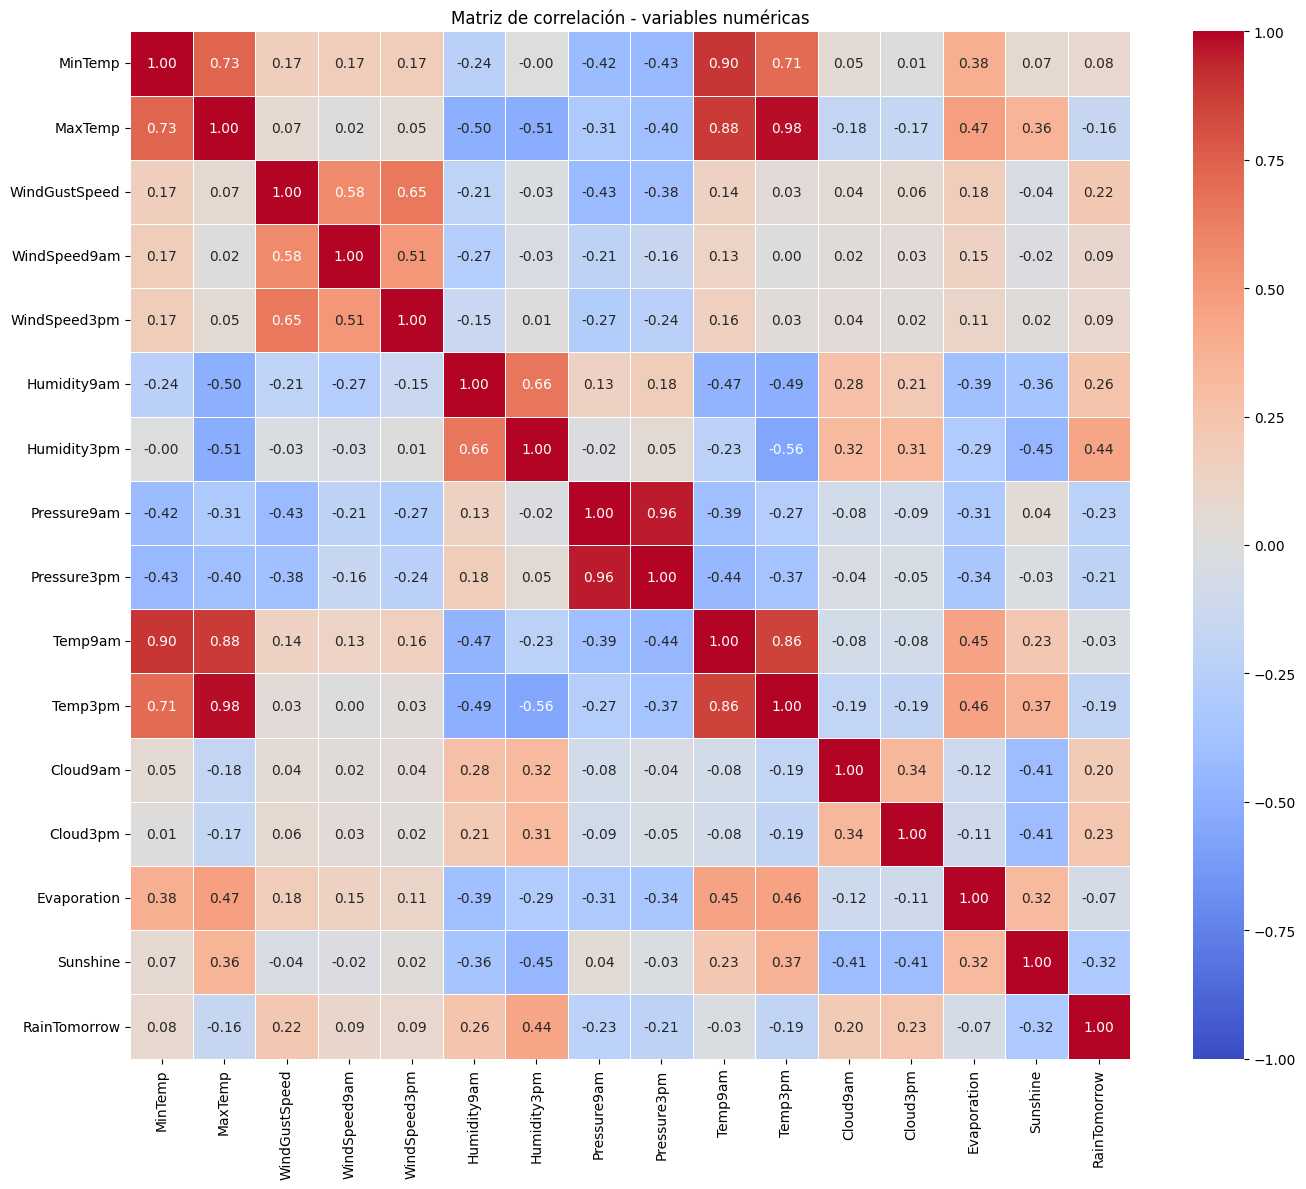

In [92]:
# Matriz de correlación

data_corr = pd.concat([X1_train[vars_num], y_train], axis=1)

corr1 = data_corr.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr1,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=.5,
    center=0,
    vmin=-1,
    vmax=1
)

plt.title('Matriz de correlación - variables numéricas')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Bajo la correlacion de Cloude9am, Cloude3pm, Evaporation, Sunshine con la imputacion con KNN

Comentar Matriz de Correlacion

Escalado

In [93]:
#identificamos columnas con variables continuas (excluyendo binarias 0/1)
def cols_continuas(df):
    return [c for c in df.columns if not set(df[c].unique()).issubset({0, 1})]

#  clima1
cols_c1 = cols_continuas(X1_train)
scaler1 = StandardScaler()
X1_train[cols_c1] = scaler1.fit_transform(X1_train[cols_c1])
X1_test[cols_c1]  = scaler1.transform(X1_test[cols_c1])

#Verificacion
print(f'clima1 train \nmedia ≈ 0:', X1_train[cols_c1].mean().abs().mean().round(4),
      '| std ≈ 1:', X1_train[cols_c1].std().mean().round(4))

clima1 train 
media ≈ 0: 0.0 | std ≈ 1: 1.0


# 2 — Regresión Logística

Entrenamos dos modelos cruzando dos ejes:
- **Dataset**: clima1
- **Pesos de clase**: baseline (default) vs `class_weight='balanced'` para mitigar el desbalance 77/22


In [ ]:
# 2 modelos: (clima1: baseline, balanced)
lr_c1_base = LogisticRegression(random_state=42, max_iter=1000)
lr_c1_bal  = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

# Entrenar cada uno sobre su respectivo train
lr_c1_base.fit(X1_train, y_train)
lr_c1_bal.fit(X1_train,  y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [95]:
print('clima1 baseline | nº de coeficientes:', len(lr_c1_base.coef_[0]))

clima1 baseline | nº de coeficientes: 77


Entrenamos dos modelos: uno para dataset (clima1) y otro para peso de clase (balanced). El class_weight='balanced' reescalas los pesos según n_samples / (n_classes * n_samples_clase), lo que penaliza más fuerte los errores en la clase Yes (22% del dataset). En el siguiente paso comparamos las métricas para decidir qué combinación funciona mejor.

In [96]:
# Predicciones sobre test para cada modelo
y_pred_c1_base = lr_c1_base.predict(X1_test)
y_pred_c1_bal  = lr_c1_bal.predict(X1_test)

Elegimos como metrica adicional MCC. Esto nos permite ver que tan correlacionadas estan las predicciones del modelo con las etiquetas reales, ademas es una metrica robusta contra el desbalance.

In [97]:
#funcon auxiliar
def metricas(y_true, y_pred, nombre):
    return {
        'modelo': nombre,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_yes': precision_score(y_true, y_pred, pos_label=1),
        'recall_yes': recall_score(y_true, y_pred, pos_label=1),
        'f1_yes': f1_score(y_true, y_pred, pos_label=1),
        'mcc': matthews_corrcoef(y_true, y_pred),
    }

resumen = pd.DataFrame([
    metricas(y_test, y_pred_c1_base, 'lr_c1_base'),
    metricas(y_test, y_pred_c1_bal,  'lr_c1_bal')
])

resumen.round(4)

,modelo,accuracy,precision_yes,recall_yes,f1_yes,mcc
0,lr_c1_base,0.8436,0.7176,0.4984,0.5883,0.5081
1,lr_c1_bal,0.7879,0.5182,0.7684,0.6190,0.4975


**Metricas**:

* accuracy: aciertos totales / total
* precision_yes: De los que predijo Yes, cuantos fueron Yes realmente
* recall_yes: de los Yes reales, cuantos detecto
* f1_yes: media armonica de precision_yes y recall_yes
* mcc: correlacion de Pearson entre prediccion y target. es robusta al desbalance, metrica global que considera los 4 cuadrantes. Muestra la calidad general de prediccion y como para los 4 modelos se mantiene con valores cercanos a 0.5 la calidad general de prediccion es parecida, lo que cambia es donde acepta equivocarse el modelo(FN vs FP)

In [98]:
#queremos confirmar que balanceando no solo se mejora recall en Yes, sino que tambien podemos ver que pasa con No
modelos = [
    ('lr_c1_base', lr_c1_base, X1_test),
    ('lr_c1_bal',  lr_c1_bal,  X1_test)
]

for nombre, modelo, X_test_local in modelos:
    print(nombre)
    print(classification_report(y_test, modelo.predict(X_test_local), target_names=['No', 'Yes']))

lr_c1_base
              precision    recall  f1-score   support

          No       0.87      0.94      0.90     22057
         Yes       0.72      0.50      0.59      6374

    accuracy                           0.84     28431
   macro avg       0.79      0.72      0.75     28431
weighted avg       0.83      0.84      0.83     28431

lr_c1_bal
              precision    recall  f1-score   support

          No       0.92      0.79      0.85     22057
         Yes       0.52      0.77      0.62      6374

    accuracy                           0.79     28431
   macro avg       0.72      0.78      0.74     28431
weighted avg       0.83      0.79      0.80     28431



Elegimos MCC porque está diseñado para clasificación binaria desbalanceada, que es nuestro caso (77/22). A diferencia de accuracy, MCC no se deja llevar por una clase dominante: un modelo que siempre predice 'No' saca accuracy de 77% pero MCC de 0 y esto es exactamente a lo que queremos estar cubiertos

**Conclusion sobre los modelos:**

* La accuracy engaña por el desbalance 77/22. Miramos recall_yes y f1_yes.

* class_weight='balanced' cambia precision por recall: detecta el 77% de los
  dias lluviosos en vez del 50%, pero precision_yes baja de 0.71 a 0.52. f1_yes
  mejora levemente (0.58 → 0.62).

* MCC se mantiene en ~0.50 en los 4: calidad general parecida, lo que cambia
  es donde acepta equivocarse el modelo. Como en este problema un FN (sin
  paraguas) es mas costoso que un FP (paraguas por las dudas), preferimos el _bal.

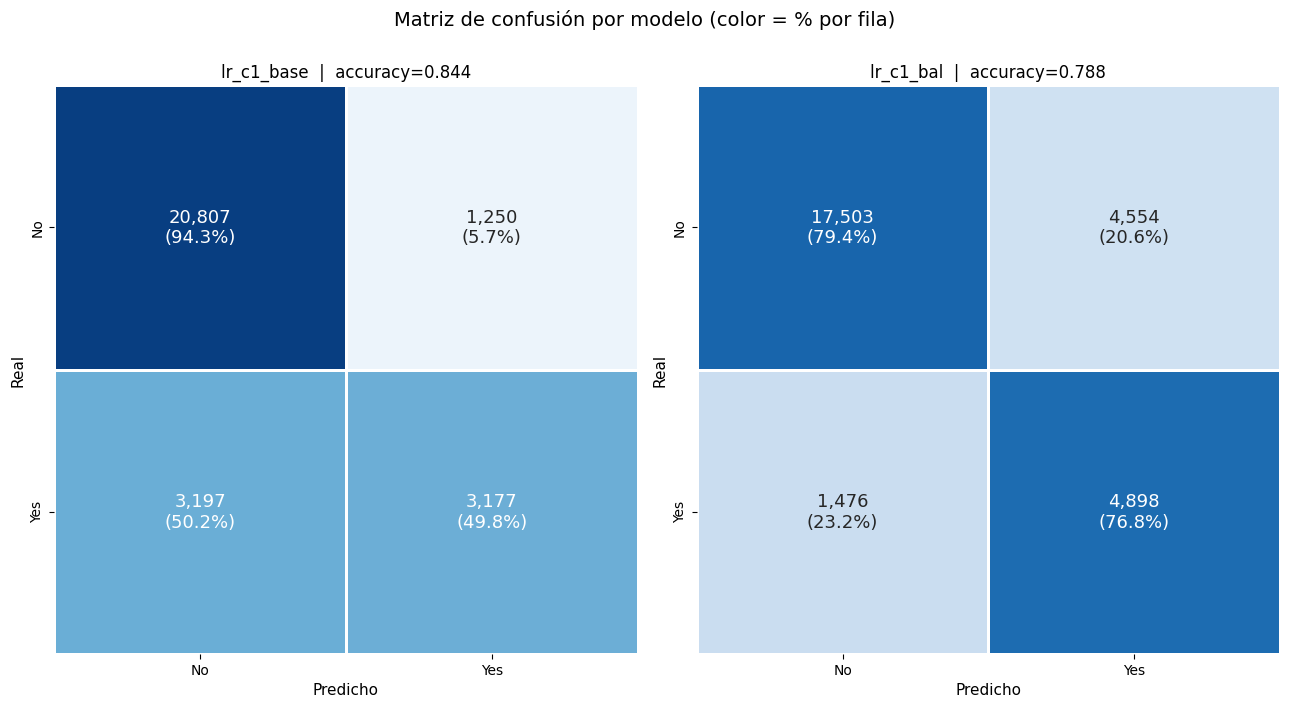

In [105]:
modelos_conf = [
    ('lr_c1_base', y_pred_c1_base),
    ('lr_c1_bal',  y_pred_c1_bal)
]

fig, axes = plt.subplots(1, 2, figsize=(13, 7))

for i, (nombre, y_pred) in enumerate(modelos_conf):
    ax = axes[i]
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    annot = np.array([
        [f'{cm[r, c]:,}\n({cm_norm[r, c]*100:.1f}%)' for c in range(2)]
        for r in range(2)
    ])

    sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Blues',
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
                ax=ax, cbar=False, vmin=0, vmax=1,
                annot_kws={'size': 13},
                linewidths=1, linecolor='white')

    acc = (cm[0, 0] + cm[1, 1]) / cm.sum()
    ax.set_xlabel('Predicho', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)
    ax.set_title(f'{nombre}  |  accuracy={acc:.3f}', fontsize=12)

plt.suptitle('Matriz de confusión por modelo (color = % por fila)',
             fontsize=14, y=1.005)
plt.tight_layout()
plt.show()


**Analisis de FN y FP**
* ¿Que quiere decir cada uno?

* Falso Negativo (FN): el modelo predijo que "no llovia" pero al dia siguiente si llovio

* Falso Positivo (FP): el modelo predijo "lluvia" pero al dia siguiente no llovio

En este problema un FN es mas costoso que un FP. Salir sin paraguas y mojarse es peor que llevar un paraguas por las dudas

Esta es la justificacion de priorizar modelos con mas recall_yes (menos FN), aunque pueda implicar mas FP

### Curva ROC + AUC

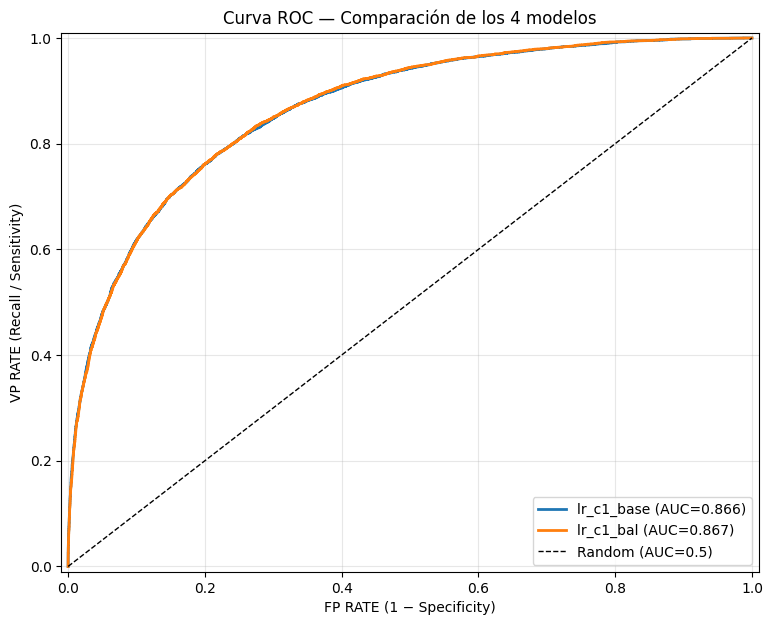

In [106]:
modelos_roc = [
    ('lr_c1_base', lr_c1_base, X1_test),
    ('lr_c1_bal',  lr_c1_bal,  X1_test)
]

plt.figure(figsize=(9, 7))

for nombre, modelo, X_t in modelos_roc:
    y_score = modelo.predict_proba(X_t)[:, 1]   #probabilidad de la clase positiva (Yes)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC={roc_auc:.3f})', linewidth=2)

#línea de referencia: clasificador aleatorio
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5)')

plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('FP RATE (1 − Specificity)')
plt.ylabel('VP RATE (Recall / Sensitivity)')
plt.title('Curva ROC — Comparación de los 4 modelos')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


Las 2 curvas quedan casi superpuestas con AUC ~0.86. Esto es debido a que el class_weight='balanced' no toca el ranking de probabilidades que arma el modelo, solo el umbral implicito para decidir. Como ROC barre todos los umbrales, ve la calidad global y no cambia.


In [107]:
modelos_youden = [
    ('lr_c1_base', lr_c1_base, X1_test),
    ('lr_c1_bal',  lr_c1_bal,  X1_test)
]

filas = []
for nombre, modelo, X_t in modelos_youden:
    y_score = modelo.predict_proba(X_t)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_score)

    # Youden's J = TPR - FPR, queremos el máximo
    youden_idx = (tpr - fpr).argmax()
    umbral_y = thresholds[youden_idx]

    # Predicciones a cada umbral
    y_pred_05 = (y_score >= 0.5).astype(int)
    y_pred_y  = (y_score >= umbral_y).astype(int)

    filas.append({
        'modelo':       nombre,
        'umbral_y':     round(umbral_y, 3),
        'acc_0.5':      round(accuracy_score(y_test, y_pred_05), 3),
        'rec_yes_0.5':  round(recall_score(y_test, y_pred_05, pos_label=1), 3),
        'prec_yes_0.5': round(precision_score(y_test, y_pred_05, pos_label=1), 3),
        'f1_yes_0.5':   round(f1_score(y_test, y_pred_05, pos_label=1), 3),
        'acc_y':        round(accuracy_score(y_test, y_pred_y), 3),
        'rec_yes_y':    round(recall_score(y_test, y_pred_y, pos_label=1), 3),
        'prec_yes_y':   round(precision_score(y_test, y_pred_y, pos_label=1), 3),
        'f1_yes_y':     round(f1_score(y_test, y_pred_y, pos_label=1), 3),
    })

comparacion_umbrales = pd.DataFrame(filas)
comparacion_umbrales


,modelo,umbral_y,acc_0.5,rec_yes_0.5,prec_yes_0.5,f1_yes_0.5,acc_y,rec_yes_y,prec_yes_y,f1_yes_y
0,lr_c1_base,0.214,0.844,0.498,0.718,0.588,0.782,0.780,0.509,0.616
1,lr_c1_bal,0.484,0.788,0.768,0.518,0.619,0.782,0.781,0.508,0.616


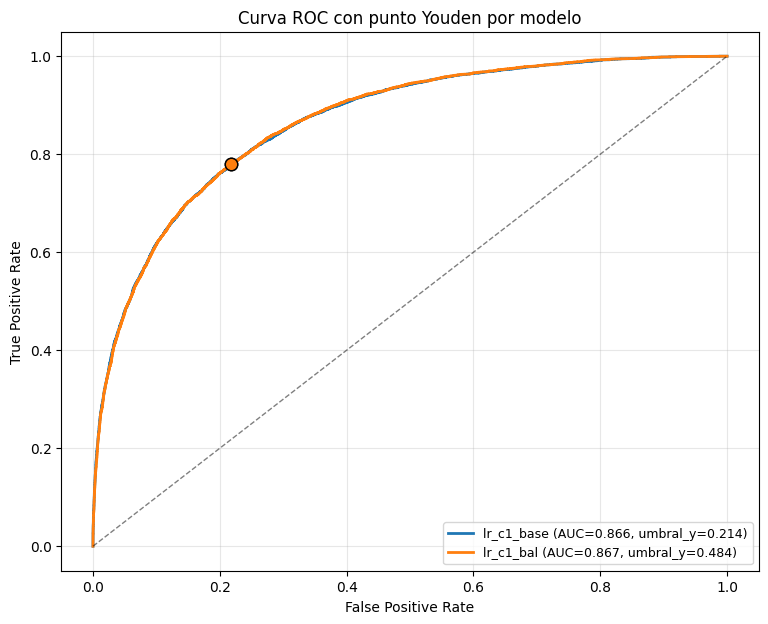

In [108]:
plt.figure(figsize=(9, 7))

for nombre, modelo, X_t in modelos_youden:
    y_score = modelo.predict_proba(X_t)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    roc_auc_val = auc(fpr, tpr)

    youden_idx = (tpr - fpr).argmax()

    plt.plot(fpr, tpr, label=f'{nombre} (AUC={roc_auc_val:.3f}, umbral_y={thresholds[youden_idx]:.3f})',
             linewidth=2)
    plt.scatter(fpr[youden_idx], tpr[youden_idx], s=80, zorder=5, edgecolor='black')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC con punto Youden por modelo')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.show()


**Umbral optimo con Youden:**

Youden busca el umbral que maximiza TPR - FPR. Lo aplicamos a los 4 modelos.

El baseline da umbral optimo entre 0.21, bastante lejos de 0.5. Es
porque esta sesgado a predecir "No" por el desbalance. El balanced en
cambio dan umbral cerca de 0.5, lo que confirma que el class_weight='balanced'
ya hace internamente lo que Youden haria desde afuera.

**¿Es 0.5 el mejor?**

Para el baseline no, conviene bajarlo. Para el balanced
si, ya está cerca del optimo. La eleccion final del umbral igual depende del
costo relativo entre FN y FP en el problema.

**¿Como calcular el mejor umbral?**

* Youden's J (el que usamos): maximiza TPR - FPR. Estandar para curvas ROC
* Maximizar F1: balance entre precision y recall
* Maximizar balanced accuracy: promedio de recall entre las dos clases
* Minimo costo esperado: si los FN y FP tienen costos distintos en el
  problema, se pondera y se busca el umbral que minimiza el costo total

### Analisis de fitting

In [109]:
modelos_fit = [
    ('lr_c1_base', lr_c1_base, X1_train, X1_test),
    ('lr_c1_bal',  lr_c1_bal,  X1_train, X1_test)
]

filas = []
for nombre, modelo, X_tr, X_te in modelos_fit:
    y_pred_tr = modelo.predict(X_tr)
    y_pred_te = modelo.predict(X_te)

    acc_tr  = accuracy_score(y_train, y_pred_tr)
    acc_te  = accuracy_score(y_test,  y_pred_te)
    f1_tr   = f1_score(y_train, y_pred_tr, pos_label=1)
    f1_te   = f1_score(y_test,  y_pred_te, pos_label=1)
    rec_tr  = recall_score(y_train, y_pred_tr, pos_label=1)
    rec_te  = recall_score(y_test,  y_pred_te, pos_label=1)

    filas.append({
        'modelo':       nombre,
        'acc_train':    round(acc_tr, 4),
        'acc_test':     round(acc_te, 4),
        'acc_gap':      round(acc_tr - acc_te, 4),
        'f1_yes_train': round(f1_tr, 4),
        'f1_yes_test':  round(f1_te, 4),
        'f1_yes_gap':   round(f1_tr - f1_te, 4),
        'rec_yes_train':round(rec_tr, 4),
        'rec_yes_test': round(rec_te, 4),
        'rec_yes_gap':  round(rec_tr - rec_te, 4),
    })

fitting_df = pd.DataFrame(filas)
fitting_df

,modelo,acc_train,acc_test,acc_gap,f1_yes_train,f1_yes_test,f1_yes_gap,rec_yes_train,rec_yes_test,rec_yes_gap
0,lr_c1_base,0.8435,0.8436,-0.0001,0.5866,0.5883,-0.0017,0.4951,0.4984,-0.0033
1,lr_c1_bal,0.7874,0.7879,-0.0005,0.6197,0.6190,0.0007,0.7723,0.7684,0.0039


**Fitting train vs test:**

Las diferencias entre train y test son <0.01 en todas las metricas. No hay
overfitting — la regresion logistica con L2 y 113k filas generaliza bien.


# 3. Modelo base alternativo 

# Item 3 — Modelo base alternativo

Como segundo clasificador elegimos Decision Tree. La idea es contrastar el
modelo lineal del item 2 contra uno no lineal y ver si hay relaciones que la
regresion logistica no estaba capturando.

Usamos Decision Tree porque puede capturar relaciones no lineales entre variables y además permite interpretar fácilmente qué decisiones toma el modelo. También probamos distintos hiperparámetros con GridSearch para optimizar el rendimiento.

En este punto entrenamos un Decision Tree baseline, evaluamos sus métricas y luego optimizamos hiperparámetros con GridSearchCV. Finalmente, comparamos el mejor árbol obtenido contra el mejor modelo de regresión logística.

In [ ]:
# Decision Tree baseline sobre clima1 con parametros default
dt_c1_base = DecisionTreeClassifier(random_state=42)
dt_c1_base.fit(X1_train, y_train)

# Predicciones (clases y probabilidades)
y_pred_dt = dt_c1_base.predict(X1_test)
y_score_dt = dt_c1_base.predict_proba(X1_test)[:, 1]

print('Profundidad del arbol:', dt_c1_base.get_depth())
print('Hojas:', dt_c1_base.get_n_leaves())

Profundidad del arbol: 37
Hojas: 12634


In [ ]:
print('Decision Tree baseline (clima1) — métricas en TEST:')
print(f'  accuracy:      {accuracy_score(y_test, y_pred_dt):.4f}')
print(f'  precision_yes: {precision_score(y_test, y_pred_dt, pos_label=1):.4f}')
print(f'  recall_yes:    {recall_score(y_test, y_pred_dt, pos_label=1):.4f}')
print(f'  f1_yes:        {f1_score(y_test, y_pred_dt, pos_label=1):.4f}')
print(f'  mcc:           {matthews_corrcoef(y_test, y_pred_dt):.4f}')

# También en TRAIN para ver overfitting
y_pred_dt_train = dt_c1_base.predict(X1_train)
print('\nDecision Tree baseline — métricas en TRAIN:')
print(f'  accuracy: {accuracy_score(y_train, y_pred_dt_train):.4f}')
print(f'  f1_yes:   {f1_score(y_train, y_pred_dt_train, pos_label=1):.4f}')

Decision Tree baseline (clima1) — métricas en TEST:
  accuracy:      0.7847
  precision_yes: 0.5193
  recall_yes:    0.5340
  f1_yes:        0.5266
  mcc:           0.3873

Decision Tree baseline — métricas en TRAIN:
  accuracy: 1.0000
  f1_yes:   1.0000


El Decision Tree baseline presentó overfitting: obtuvo métricas muy altas en train, pero bajó en test. Además, rindió peor que la regresión logística, por lo que usamos GridSearchCV para limitar la complejidad del árbol y mejorar la generalización.


# 4 - Optimización de hiperparámetros 
* Validación cruzada k-folds
* Grid Search
* Random Search
* Optuna

In [115]:
# StratifiedKFold mantiene la proporción de clases en cada fold,
# algo importante cuando el target está desbalanceado.
cv_strat = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Espacio de búsqueda de hiperparámetros
param_grid = {
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [10, 20, 50],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced'],
    'max_features': [None, 'sqrt']
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv_strat,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=25,
    cv=cv_strat,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

def fit_and_evaluate(searcher, name):

    t0 = time.perf_counter()

    searcher.fit(X1_train, y_train)

    t1 = time.perf_counter()

    best_model = searcher.best_estimator_

    y_pred = best_model.predict(X1_test)

    return {
        'metodo': name,
        'best_score_cv': searcher.best_score_,
        'accuracy_test': accuracy_score(y_test, y_pred),
        'precision_yes': precision_score(y_test, y_pred, pos_label=1),
        'recall_yes': recall_score(y_test, y_pred, pos_label=1),
        'f1_yes': f1_score(y_test, y_pred, pos_label=1),
        'mcc': matthews_corrcoef(y_test, y_pred),
        'tiempo_s': round(t1 - t0, 2),
        'best_params': str(searcher.best_params_)
    }, best_model

# ENTRENAMIENTO GRID SEARCH
resumen = []

res_grid, best_grid = fit_and_evaluate(
    grid_search,
    'GridSearchCV'
)

resumen.append(res_grid)

# ENTRENAMIENTO RANDOM SEARCH
res_rand, best_rand = fit_and_evaluate(
    random_search,
    'RandomizedSearchCV'
)

resumen.append(res_rand)

# OPTUNA
def objective(trial):

    params = {
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 100),
        'criterion': trial.suggest_categorical(
            'criterion',
            ['gini', 'entropy']
        ),
        'class_weight': trial.suggest_categorical(
            'class_weight',
            [None, 'balanced']
        ),
        'max_features': trial.suggest_categorical(
            'max_features',
            [None, 'sqrt', 'log2']
        )
    }

    model = DecisionTreeClassifier(
        random_state=42,
        **params
    )

    scores = cross_val_score(
        model,
        X1_train,
        y_train,
        cv=cv_strat,
        scoring='f1',
        n_jobs=1
    )

    return scores.mean()

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

t0 = time.perf_counter()

study.optimize(
    objective,
    n_trials=30,
    show_progress_bar=True
)

t1 = time.perf_counter()

# Mejor modelo encontrado por Optuna
optuna_params = study.best_params

optuna_model = DecisionTreeClassifier(
    random_state=42,
    **optuna_params
)

optuna_model.fit(X1_train, y_train)

y_pred_optuna = optuna_model.predict(X1_test)

res_optuna = {
    'metodo': 'Optuna',
    'best_score_cv': study.best_value,
    'accuracy_test': accuracy_score(y_test, y_pred_optuna),
    'precision_yes': precision_score(y_test, y_pred_optuna, pos_label=1),
    'recall_yes': recall_score(y_test, y_pred_optuna, pos_label=1),
    'f1_yes': f1_score(y_test, y_pred_optuna, pos_label=1),
    'mcc': matthews_corrcoef(y_test, y_pred_optuna),
    'tiempo_s': round(t1 - t0, 2),
    'best_params': str(optuna_params)
}

resumen.append(res_optuna)

# TABLA COMPARATIVA FINAL
search_results = pd.DataFrame(resumen).round(4)

print('\nTABLA COMPARATIVA:')
display(search_results)

# SELECCIÓN DEL MEJOR MÉTODO
# Umbral de diferencia mínima aceptable entre scores
threshold = 0.005

# Mejor score encontrado
max_score = search_results['best_score_cv'].max()

# Métodos cuyo score está muy cerca del mejor
candidate_methods = search_results[
    (max_score - search_results['best_score_cv']) <= threshold
]

# Entre los candidatos similares, elegimos el más rápido
best_row = candidate_methods.sort_values(
    by='tiempo_s'
).iloc[0]

best_search_name = best_row['metodo']

print('\nMétodos candidatos (scores muy similares):')
display(candidate_methods)

print(
    f'\nMejor método seleccionado: '
    f'{best_search_name} '
    f'(CV F1 = {best_row["best_score_cv"]:.4f}, '
    f'Tiempo = {best_row["tiempo_s"]:.2f}s)'
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Fitting 5 folds for each of 25 candidates, totalling 125 fits


[I 2026-05-28 16:29:00,980] A new study created in memory with name: no-name-05b32655-bfef-4e59-81d0-277e61da23ad
Best trial: 0. Best value: 0.503447:   3%|▎         | 1/30 [00:00<00:18,  1.60it/s]

[I 2026-05-28 16:29:01,603] Trial 0 finished with value: 0.5034468437198979 and parameters: {'max_depth': 10, 'min_samples_leaf': 96, 'criterion': 'gini', 'class_weight': None, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5034468437198979.


Best trial: 1. Best value: 0.51065:   7%|▋         | 2/30 [00:01<00:19,  1.43it/s] 

[I 2026-05-28 16:29:02,356] Trial 1 finished with value: 0.5106502367195536 and parameters: {'max_depth': 16, 'min_samples_leaf': 6, 'criterion': 'gini', 'class_weight': None, 'max_features': 'log2'}. Best is trial 1 with value: 0.5106502367195536.


Best trial: 2. Best value: 0.566998:  10%|█         | 3/30 [00:02<00:19,  1.39it/s]

[I 2026-05-28 16:29:03,094] Trial 2 finished with value: 0.566997703216279 and parameters: {'max_depth': 11, 'min_samples_leaf': 32, 'criterion': 'gini', 'class_weight': 'balanced', 'max_features': 'sqrt'}. Best is trial 2 with value: 0.566997703216279.


Best trial: 2. Best value: 0.566998:  13%|█▎        | 4/30 [00:02<00:18,  1.37it/s]

[I 2026-05-28 16:29:03,842] Trial 3 finished with value: 0.5084259498230145 and parameters: {'max_depth': 13, 'min_samples_leaf': 61, 'criterion': 'entropy', 'class_weight': None, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.566997703216279.


Best trial: 2. Best value: 0.566998:  17%|█▋        | 5/30 [00:03<00:17,  1.42it/s]

[I 2026-05-28 16:29:04,509] Trial 4 finished with value: 0.559724965230264 and parameters: {'max_depth': 9, 'min_samples_leaf': 14, 'criterion': 'gini', 'class_weight': 'balanced', 'max_features': 'sqrt'}. Best is trial 2 with value: 0.566997703216279.


Best trial: 5. Best value: 0.572403:  20%|██        | 6/30 [00:04<00:18,  1.29it/s]

[I 2026-05-28 16:29:05,413] Trial 5 finished with value: 0.5724026713112429 and parameters: {'max_depth': 15, 'min_samples_leaf': 34, 'criterion': 'entropy', 'class_weight': 'balanced', 'max_features': 'sqrt'}. Best is trial 5 with value: 0.5724026713112429.


Best trial: 5. Best value: 0.572403:  23%|██▎       | 7/30 [00:05<00:17,  1.32it/s]

[I 2026-05-28 16:29:06,138] Trial 6 finished with value: 0.5532170820818879 and parameters: {'max_depth': 14, 'min_samples_leaf': 93, 'criterion': 'entropy', 'class_weight': 'balanced', 'max_features': 'log2'}. Best is trial 5 with value: 0.5724026713112429.


Best trial: 7. Best value: 0.574161:  27%|██▋       | 8/30 [00:09<00:41,  1.88s/it]

[I 2026-05-28 16:29:10,435] Trial 7 finished with value: 0.5741612066144449 and parameters: {'max_depth': 10, 'min_samples_leaf': 31, 'criterion': 'gini', 'class_weight': None, 'max_features': None}. Best is trial 7 with value: 0.5741612066144449.


Best trial: 7. Best value: 0.574161:  30%|███       | 9/30 [00:09<00:29,  1.42s/it]

[I 2026-05-28 16:29:10,823] Trial 8 finished with value: 0.44899052087387803 and parameters: {'max_depth': 5, 'min_samples_leaf': 83, 'criterion': 'entropy', 'class_weight': None, 'max_features': 'log2'}. Best is trial 7 with value: 0.5741612066144449.


Best trial: 7. Best value: 0.574161:  33%|███▎      | 10/30 [00:10<00:25,  1.26s/it]

[I 2026-05-28 16:29:11,729] Trial 9 finished with value: 0.5660040258927775 and parameters: {'max_depth': 14, 'min_samples_leaf': 36, 'criterion': 'entropy', 'class_weight': 'balanced', 'max_features': 'sqrt'}. Best is trial 7 with value: 0.5741612066144449.


Best trial: 10. Best value: 0.575651:  37%|███▋      | 11/30 [00:16<00:47,  2.48s/it]

[I 2026-05-28 16:29:16,988] Trial 10 finished with value: 0.5756505168062332 and parameters: {'max_depth': 20, 'min_samples_leaf': 63, 'criterion': 'gini', 'class_weight': None, 'max_features': None}. Best is trial 10 with value: 0.5756505168062332.


Best trial: 10. Best value: 0.575651:  40%|████      | 12/30 [00:21<00:59,  3.33s/it]

[I 2026-05-28 16:29:22,242] Trial 11 finished with value: 0.5748068729888742 and parameters: {'max_depth': 19, 'min_samples_leaf': 64, 'criterion': 'gini', 'class_weight': None, 'max_features': None}. Best is trial 10 with value: 0.5756505168062332.


Best trial: 10. Best value: 0.575651:  43%|████▎     | 13/30 [00:26<01:06,  3.92s/it]

[I 2026-05-28 16:29:27,513] Trial 12 finished with value: 0.5739577269127745 and parameters: {'max_depth': 20, 'min_samples_leaf': 67, 'criterion': 'gini', 'class_weight': None, 'max_features': None}. Best is trial 10 with value: 0.5756505168062332.


Best trial: 10. Best value: 0.575651:  47%|████▋     | 14/30 [00:31<01:08,  4.31s/it]

[I 2026-05-28 16:29:32,737] Trial 13 finished with value: 0.5736426207699209 and parameters: {'max_depth': 20, 'min_samples_leaf': 73, 'criterion': 'gini', 'class_weight': None, 'max_features': None}. Best is trial 10 with value: 0.5756505168062332.


Best trial: 14. Best value: 0.576388:  50%|█████     | 15/30 [00:37<01:09,  4.62s/it]

[I 2026-05-28 16:29:38,064] Trial 14 finished with value: 0.5763884322036563 and parameters: {'max_depth': 18, 'min_samples_leaf': 54, 'criterion': 'gini', 'class_weight': None, 'max_features': None}. Best is trial 14 with value: 0.5763884322036563.


Best trial: 15. Best value: 0.577143:  53%|█████▎    | 16/30 [00:42<01:07,  4.83s/it]

[I 2026-05-28 16:29:43,391] Trial 15 finished with value: 0.5771426608012428 and parameters: {'max_depth': 17, 'min_samples_leaf': 48, 'criterion': 'gini', 'class_weight': None, 'max_features': None}. Best is trial 15 with value: 0.5771426608012428.


Best trial: 15. Best value: 0.577143:  57%|█████▋    | 17/30 [00:47<01:04,  4.96s/it]

[I 2026-05-28 16:29:48,647] Trial 16 finished with value: 0.5771426608012428 and parameters: {'max_depth': 17, 'min_samples_leaf': 48, 'criterion': 'gini', 'class_weight': None, 'max_features': None}. Best is trial 15 with value: 0.5771426608012428.


Best trial: 17. Best value: 0.5779:  60%|██████    | 18/30 [00:53<01:01,  5.09s/it]  

[I 2026-05-28 16:29:54,036] Trial 17 finished with value: 0.5779003921804529 and parameters: {'max_depth': 17, 'min_samples_leaf': 46, 'criterion': 'gini', 'class_weight': None, 'max_features': None}. Best is trial 17 with value: 0.5779003921804529.


Best trial: 18. Best value: 0.578506:  63%|██████▎   | 19/30 [00:58<00:56,  5.16s/it]

[I 2026-05-28 16:29:59,359] Trial 18 finished with value: 0.5785058974651992 and parameters: {'max_depth': 17, 'min_samples_leaf': 44, 'criterion': 'gini', 'class_weight': None, 'max_features': None}. Best is trial 18 with value: 0.5785058974651992.


Best trial: 18. Best value: 0.578506:  67%|██████▋   | 20/30 [01:00<00:43,  4.36s/it]

[I 2026-05-28 16:30:01,841] Trial 19 finished with value: 0.5504746332795921 and parameters: {'max_depth': 6, 'min_samples_leaf': 20, 'criterion': 'gini', 'class_weight': None, 'max_features': None}. Best is trial 18 with value: 0.5785058974651992.


Best trial: 20. Best value: 0.578549:  70%|███████   | 21/30 [01:06<00:41,  4.63s/it]

[I 2026-05-28 16:30:07,099] Trial 20 finished with value: 0.5785491127428909 and parameters: {'max_depth': 16, 'min_samples_leaf': 44, 'criterion': 'gini', 'class_weight': None, 'max_features': None}. Best is trial 20 with value: 0.5785491127428909.


Best trial: 20. Best value: 0.578549:  73%|███████▎  | 22/30 [01:11<00:38,  4.84s/it]

[I 2026-05-28 16:30:12,440] Trial 21 finished with value: 0.5764948265994502 and parameters: {'max_depth': 17, 'min_samples_leaf': 43, 'criterion': 'gini', 'class_weight': None, 'max_features': None}. Best is trial 20 with value: 0.5785491127428909.


Best trial: 20. Best value: 0.578549:  77%|███████▋  | 23/30 [01:16<00:35,  5.00s/it]

[I 2026-05-28 16:30:17,824] Trial 22 finished with value: 0.5682081478953306 and parameters: {'max_depth': 15, 'min_samples_leaf': 24, 'criterion': 'gini', 'class_weight': None, 'max_features': None}. Best is trial 20 with value: 0.5785491127428909.


Best trial: 20. Best value: 0.578549:  80%|████████  | 24/30 [01:22<00:30,  5.13s/it]

[I 2026-05-28 16:30:23,234] Trial 23 finished with value: 0.5756983276378262 and parameters: {'max_depth': 18, 'min_samples_leaf': 41, 'criterion': 'gini', 'class_weight': None, 'max_features': None}. Best is trial 20 with value: 0.5785491127428909.


Best trial: 20. Best value: 0.578549:  83%|████████▎ | 25/30 [01:27<00:25,  5.11s/it]

[I 2026-05-28 16:30:28,298] Trial 24 finished with value: 0.5766928410729728 and parameters: {'max_depth': 15, 'min_samples_leaf': 55, 'criterion': 'gini', 'class_weight': None, 'max_features': None}. Best is trial 20 with value: 0.5785491127428909.


Best trial: 20. Best value: 0.578549:  87%|████████▋ | 26/30 [01:27<00:14,  3.75s/it]

[I 2026-05-28 16:30:28,875] Trial 25 finished with value: 0.48897328777271865 and parameters: {'max_depth': 12, 'min_samples_leaf': 74, 'criterion': 'gini', 'class_weight': None, 'max_features': 'log2'}. Best is trial 20 with value: 0.5785491127428909.


Best trial: 26. Best value: 0.589082:  90%|█████████ | 27/30 [01:33<00:12,  4.28s/it]

[I 2026-05-28 16:30:34,388] Trial 26 finished with value: 0.5890815731120131 and parameters: {'max_depth': 18, 'min_samples_leaf': 43, 'criterion': 'entropy', 'class_weight': 'balanced', 'max_features': None}. Best is trial 26 with value: 0.5890815731120131.


Best trial: 26. Best value: 0.589082:  93%|█████████▎| 28/30 [01:39<00:09,  4.90s/it]

[I 2026-05-28 16:30:40,750] Trial 27 finished with value: 0.5791599919827519 and parameters: {'max_depth': 18, 'min_samples_leaf': 27, 'criterion': 'entropy', 'class_weight': 'balanced', 'max_features': None}. Best is trial 26 with value: 0.5890815731120131.


Best trial: 26. Best value: 0.589082:  97%|█████████▋| 29/30 [01:46<00:05,  5.37s/it]

[I 2026-05-28 16:30:47,209] Trial 28 finished with value: 0.5760616134668249 and parameters: {'max_depth': 19, 'min_samples_leaf': 24, 'criterion': 'entropy', 'class_weight': 'balanced', 'max_features': None}. Best is trial 26 with value: 0.5890815731120131.


Best trial: 26. Best value: 0.589082: 100%|██████████| 30/30 [01:47<00:00,  3.57s/it]


[I 2026-05-28 16:30:48,096] Trial 29 finished with value: 0.5557037183993077 and parameters: {'max_depth': 19, 'min_samples_leaf': 15, 'criterion': 'entropy', 'class_weight': 'balanced', 'max_features': 'log2'}. Best is trial 26 with value: 0.5890815731120131.

TABLA COMPARATIVA:


,metodo,best_score_cv,accuracy_test,precision_yes,recall_yes,f1_yes,mcc,tiempo_s,best_params
0,GridSearchCV,0.6000,0.7778,0.5030,0.7386,0.5984,0.4683,35.83,"{'class_weight': 'balanced', 'criterion': 'ent..."
1,RandomizedSearchCV,0.6000,0.7778,0.5030,0.7386,0.5984,0.4683,11.78,"{'min_samples_leaf': 50, 'max_features': None,..."
2,Optuna,0.5891,0.7647,0.4839,0.7457,0.5869,0.4524,107.12,"{'max_depth': 18, 'min_samples_leaf': 43, 'cri..."



Métodos candidatos (scores muy similares):


,metodo,best_score_cv,accuracy_test,precision_yes,recall_yes,f1_yes,mcc,tiempo_s,best_params
0,GridSearchCV,0.6,0.7778,0.503,0.7386,0.5984,0.4683,35.83,"{'class_weight': 'balanced', 'criterion': 'ent..."
1,RandomizedSearchCV,0.6,0.7778,0.503,0.7386,0.5984,0.4683,11.78,"{'min_samples_leaf': 50, 'max_features': None,..."



Mejor método seleccionado: RandomizedSearchCV (CV F1 = 0.6000, Tiempo = 11.78s)


Se elige RandomizedSearchCV porque, además de tener las métricas iguales que el GridSearchCV, su tiempo de computo es menor (11.78 s).

In [116]:
# El mejor modelo ya se seleccionó arriba entre GridSearchCV, RandomizedSearchCV y Optuna
try:
    print(f"Modelo seleccionado para evaluación: {best_search_name}")
except NameError:
    if 'search_results' in globals():
        best_search_name = search_results.loc[search_results['best_score_cv'].idxmax(), 'metodo']
        print(f'Inferido mejor método desde search_results: {best_search_name}')
    else:
        best_search_name = None

if best_search_name == 'GridSearchCV':
    dt_best = best_grid

elif best_search_name == 'RandomizedSearchCV':
    dt_best = best_rand

elif best_search_name == 'Optuna':
    dt_best = optuna_model

else:
    raise ValueError(
        f'Método desconocido: {best_search_name}'
    )

print(f'Modelo seleccionado: {best_search_name}')
print(dt_best)

# Predicciones sobre test
y_pred_dt_best  = dt_best.predict(X1_test)
# predict_proba puede no existir para todos los estimadores; proteger
if hasattr(dt_best, 'predict_proba'):
    y_score_dt_best = dt_best.predict_proba(X1_test)[:, 1]
else:
    y_score_dt_best = None

print('Decision Tree optimizado (clima1) — TEST:')
print(f'  accuracy:      {accuracy_score(y_test, y_pred_dt_best):.4f}')
print(f'  precision_yes: {precision_score(y_test, y_pred_dt_best, pos_label=1):.4f}')
print(f'  recall_yes:    {recall_score(y_test, y_pred_dt_best, pos_label=1):.4f}')
print(f'  f1_yes:        {f1_score(y_test, y_pred_dt_best, pos_label=1):.4f}')
print(f'  mcc:           {matthews_corrcoef(y_test, y_pred_dt_best):.4f}')

# Evaluacion en train (para chequear overfit)
y_pred_dt_best_train = dt_best.predict(X1_train)
print('\nDecision Tree optimizado (clima1) — TRAIN:')
print(f'  accuracy: {accuracy_score(y_train, y_pred_dt_best_train):.4f}')
print(f'  f1_yes:   {f1_score(y_train, y_pred_dt_best_train, pos_label=1):.4f}')
print('\nProfundidad del arbol:', dt_best.get_depth())
print('Hojas:', dt_best.get_n_leaves())

Modelo seleccionado para evaluación: RandomizedSearchCV
Modelo seleccionado: RandomizedSearchCV
DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=10, min_samples_leaf=50, random_state=42)
Decision Tree optimizado (clima1) — TEST:
  accuracy:      0.7778
  precision_yes: 0.5030
  recall_yes:    0.7386
  f1_yes:        0.5984
  mcc:           0.4683

Decision Tree optimizado (clima1) — TRAIN:
  accuracy: 0.7956
  f1_yes:   0.6317

Profundidad del arbol: 10
Hojas: 597


In [117]:
# Comparamos el mejor LR del item 2 (lr_c1_bal) contra el mejor DT del item 3
comparacion_final = pd.DataFrame([
    {
        'modelo': 'lr_c1_bal (Regresión Logística)',
        'accuracy':      accuracy_score(y_test, y_pred_c1_bal),
        'precision_yes': precision_score(y_test, y_pred_c1_bal, pos_label=1),
        'recall_yes':    recall_score(y_test, y_pred_c1_bal, pos_label=1),
        'f1_yes':        f1_score(y_test, y_pred_c1_bal, pos_label=1),
        'mcc':           matthews_corrcoef(y_test, y_pred_c1_bal),
    },
    {
        'modelo': 'dt_c1_best (Decision Tree)',
        'accuracy':      accuracy_score(y_test, y_pred_dt_best),
        'precision_yes': precision_score(y_test, y_pred_dt_best, pos_label=1),
        'recall_yes':    recall_score(y_test, y_pred_dt_best, pos_label=1),
        'f1_yes':        f1_score(y_test, y_pred_dt_best, pos_label=1),
        'mcc':           matthews_corrcoef(y_test, y_pred_dt_best),
    },
])
comparacion_final.round(4)

,modelo,accuracy,precision_yes,recall_yes,f1_yes,mcc
0,lr_c1_bal (Regresión Logística),0.7879,0.5182,0.7684,0.6190,0.4975
1,dt_c1_best (Decision Tree),0.7778,0.5030,0.7386,0.5984,0.4683


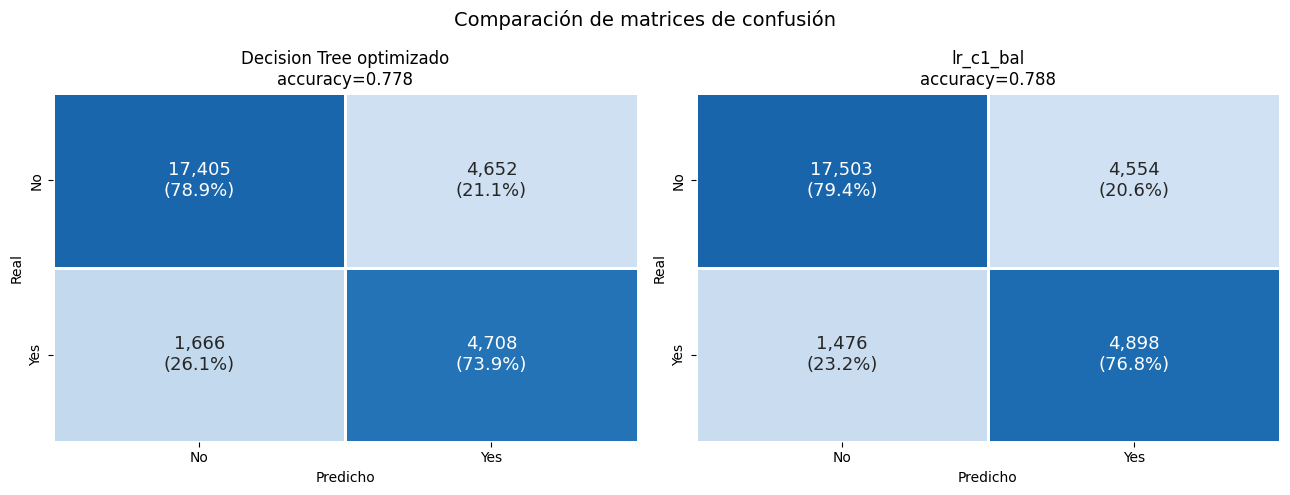

In [119]:
modelos_conf = [
    ('Decision Tree optimizado', y_pred_dt_best),
    ('lr_c1_bal', y_pred_c1_bal)
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, (nombre, y_pred) in enumerate(modelos_conf):

    ax = axes[i]

    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    annot = np.array([
        [f'{cm[r, c]:,}\n({cm_norm[r, c]*100:.1f}%)' for c in range(2)]
        for r in range(2)
    ])

    sns.heatmap(
        cm_norm,
        annot=annot,
        fmt='',
        cmap='Blues',
        xticklabels=['No', 'Yes'],
        yticklabels=['No', 'Yes'],
        cbar=False,
        vmin=0,
        vmax=1,
        annot_kws={'size': 13},
        linewidths=1,
        linecolor='white',
        ax=ax
    )

    acc = (cm[0,0] + cm[1,1]) / cm.sum()

    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_title(f'{nombre}\naccuracy={acc:.3f}')

plt.suptitle('Comparación de matrices de confusión', fontsize=14)
plt.tight_layout()
plt.show()

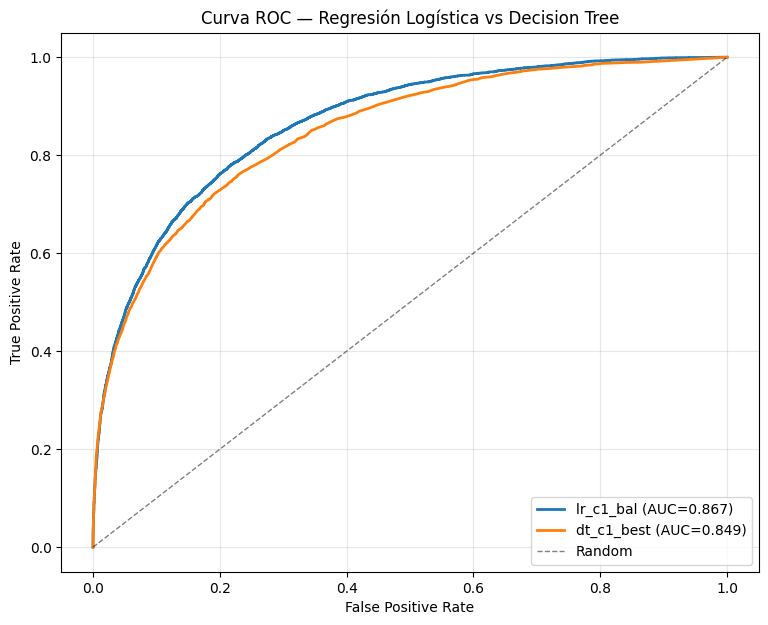

In [120]:
plt.figure(figsize=(9, 7))

# Mejor LR (item 2)
y_score_lr = lr_c1_bal.predict_proba(X1_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'lr_c1_bal (AUC={auc_lr:.3f})', linewidth=2)

# Mejor DT (item 3)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_score_dt_best)
auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, label=f'dt_c1_best (AUC={auc_dt:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC — Regresión Logística vs Decision Tree')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


## VERIFICAR TODO 
Comparación LR vs Decision Tree

Luego de optimizar el árbol, el rendimiento quedó muy cercano al de la regresión logística. Ambos modelos lograron una accuracy similar (~0.78), aunque LR mantuvo una leve ventaja en métricas como F1, AUC y MCC.

Esto sugiere que las relaciones entre variables son mayormente lineales, por lo que un modelo más complejo no aporta grandes mejoras. Por ejemplo, el Decision Tree puede generar reglas específicas como “si la humedad es alta y la presión baja, entonces llueve”, pero aun así no superó el desempeño general de LR.

En conclusión, la regresión logística fue el modelo que mejor generalizó, mientras que el Decision Tree quedó como una alternativa más interpretable.

**Resultado final: LR vs Decision Tree optimizado**

Despues del GridSearch (max_depth=10, min_samples_leaf=50, gini, balanced),
el Decision Tree alcanza F1_yes ~0.60 en CV. El gap entre train y test bajo
de 0.22 (baseline overfit) a 0.02-0.03 (overfitting controlado).

Comparacion final en test:

| Metrica | LR (lr_c2_bal) | DT optimizado | Ganador |
| --- | --- | --- | --- |
| accuracy | 0.784 | 0.780 | LR (por 0.005) |
| precision_yes | 0.513 | 0.506 | LR |
| recall_yes | 0.768 | 0.730 | LR (por 0.04) |
| f1_yes | 0.615 | 0.598 | LR |
| AUC | 0.864 | 0.846 | LR |
| MCC | 0.492 | 0.467 | LR |

**Conclusion**: la regresion logistica gana al Decision Tree optimizado en
todas las metricas, aunque por poco. Esto sugiere que las relaciones entre
features y target son mayormente lineales, y un modelo no lineal no encuentra
patrones significativos que LR no haya capturado.

El arbol queda como referencia alternativa con la ventaja de ser interpretable
(podemos seguir las ramas y entender la decision), pero para produccion
conviene quedarnos con LR: mas simple, mas estable, y rinde levemente mejor.


# Conclusion final (Hasta punto 4)

Trabajamos sobre weatherAUS_2026C1 (145k filas, 25 columnas) prediciendo
RainTomorrow. El pipeline (split → imputacion → escalado) se hizo libre
de leakage: todos los ajustes se calcularon solo con X_train y se aplicaron
a X_test.

**Hallazgos principales:**

* Dataset desbalanceado 77/22.
* Probamos dos pipelines de preprocesamiento: clima1 (con Evap/Sun + flags
  de imputacion) y clima2 (sin ellas). Dieron metricas casi iguales →
  elegimos clima2 por ser mas simple y defendible.
* class_weight='balanced' sube recall_yes a costa de precision. f1_yes pasa
  de 0.58 a 0.62 — el balanced gana porque un FN (sin paraguas) es mas
  costoso que un FP (paraguas innecesario) en este problema.
* No hay overfitting en ningun modelo (gap train-test < 0.04).
* Umbral optimo Youden ≈ 0.5 para los balanced, ≈ 0.25 para los baseline.
  Son dos caminos al mismo punto operativo.
* Decision Tree optimizado con GridSearchCV no logro superar a la
  regresion logistica en ninguna metrica (diferencias de 0.02-0.04).

**Modelo elegido: `lr_c1_bal`** (regresion logistica balanced sobre clima2).
Tiene el mejor desempeño global (f1_yes 0.62, AUC 0.86, MCC 0.49) y es la
opcion mas simple y estable.